# Notebook 02 — Figure 3: H–L Return and SDF Sharpe Ratio Across the Full K × λ Grid

**Data needed:** Full grid of cluster-month panels across both folders:
- `Results/cluster_month_panels_K_50/`  — all 13 λ values at K=50
- `Results/cluster_month_panels_all_K_except_50/`  — all other K × λ

**Cluster rankings:** `data/Cluster_Ranking.csv` provides the official
L01–L50 ranking for every (K, λ) combination.

**Output:**
- `output/figures/Figure3_HL_and_SDF_SR.{pdf,png}`
- `output/tables/Figure3_grid_HL.csv`   ← save grid for later reuse
- `output/tables/Figure3_grid_SDF_SR.csv`

**What this notebook does:**  
For each (K, λ) in the grid it:
1. Loads the cluster-month panel
2. Applies the official cluster ranking for that λ
3. Computes annualised H–L return (L50 − L01)
4. Estimates the rolling Hansen-Jagannathan SDF (window=72m) and its Sharpe ratio
5. Stores results in (K × λ) matrices and plots them as line charts

In [4]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings("ignore")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, REPO_ROOT)

from utils.data_utils import (
    load_cluster_panel, load_cluster_ranking,
    get_rank_map, pivot_and_rank,
    ann_sharpe, save_figure, save_table,
    K_GRID, RANKING_LAMBDA_STRS, LAMBDA_STR_TO_FLOAT,
    get_panel_path,
)
from utils.portfolio_utils import estimate_hj_sdf

plt.rcParams.update({
    "font.family": "serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150,
})

SDF_WINDOW = 72    # rolling window (months) for SDF estimation
RIDGE      = 1e-3  # ridge regularisation for HJ SDF

In [5]:
# ── Load cluster ranking (covers all λ values in the CSV) ─────────
ranking = load_cluster_ranking()
print("Cluster ranking loaded.")
print(f"  λ columns: {[c for c in ranking.columns if c.startswith('lambda')]}")
print(f"  Grid K values: {K_GRID}")

Cluster ranking loaded.
  λ columns: ['lambda_1000000', 'lambda_1000', 'lambda_100', 'lambda_0.0001', 'lambda_1e-05', 'lambda_1e-06', 'lambda_1e-07', 'lambda_1e-08', 'lambda_1e-09', 'lambda_1', 'lambda_0.1', 'lambda_10', 'lambda_0.001']
  Grid K values: [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]


In [6]:
# ── Verify paths ──────────────────────────────────────────────────
from utils.data_utils import K50_DIR, ALL_K_DIR, RESULTS_DIR

print(f"RESULTS_DIR : {RESULTS_DIR}")
print(f"K50_DIR     : {K50_DIR}  exists={os.path.isdir(K50_DIR)}")
print(f"ALL_K_DIR   : {ALL_K_DIR}  exists={os.path.isdir(ALL_K_DIR)}")
print()

# ── Build list of files that exist on disk ─────────────────────────
available = []
for K in K_GRID:
    for lam_str in RANKING_LAMBDA_STRS:
        for subdir in [K50_DIR, ALL_K_DIR]:
            p = os.path.join(subdir,
                             f"cluster_month_panel_K_{K}_{lam_str}.csv")
            if os.path.exists(p):
                available.append((K, lam_str, p))
                break

n_total = len(K_GRID) * len(RANKING_LAMBDA_STRS)
print(f"Files found : {len(available)} / {n_total}")
if len(available) == 0:
    raise FileNotFoundError(
        f"No panel files found under {RESULTS_DIR}.\n"
        f"Expected subdirs: cluster_month_panels_K_50/ "
        f"and cluster_month_panels_all_K_except_50/"
    )
print(f"  First: {available[0][2].split('/')[-1]}")
print(f"  Last : {available[-1][2].split('/')[-1]}")
print()

# ── Initialise result matrices ─────────────────────────────────────
import pandas as pd
hl_mat = pd.DataFrame(index=K_GRID, columns=RANKING_LAMBDA_STRS, dtype=float)
sr_mat = pd.DataFrame(index=K_GRID, columns=RANKING_LAMBDA_STRS, dtype=float)

# ── Grid scan ──────────────────────────────────────────────────────
n_done = 0
print(f"Scanning {len(available)} files...")
print("Progress every 20 files.\n")

for K, lam_str, fpath in available:
    lam_float = LAMBDA_STR_TO_FLOAT[lam_str]

    try:
        df    = load_cluster_panel(K=K, lam=lam_float)
        cr, _ = pivot_and_rank(df, lam=lam_float,
                               lam_str=lam_str,
                               ranking_df=ranking)

        # H-L annualised return (top-ranked minus bottom-ranked cluster)
        hl = (cr.iloc[:, -1] - cr.iloc[:, 0]).dropna()
        if len(hl) > 12:
            hl_mat.loc[K, lam_str] = (
                (np.prod(1 + hl) ** (12 / len(hl)) - 1) * 100
            )

        # Rolling OOS SDF Sharpe ratio
        T        = len(cr)
        sdf_rets = []
        for t in range(SDF_WINDOW, T - 1):
            train = cr.iloc[t - SDF_WINDOW: t]
            try:
                b, _   = estimate_hj_sdf(train, ridge=RIDGE)
                r_next = cr.iloc[t + 1].values
                sdf_rets.append(1.0 - b @ r_next)
            except Exception:
                pass
        if len(sdf_rets) > 12:
            sr_mat.loc[K, lam_str] = ann_sharpe(pd.Series(sdf_rets))

    except Exception as e:
        print(f"  ERROR  K={K:3d}  {lam_str:20s}  {e}")

    n_done += 1
    if n_done % 20 == 0:
        pct       = n_done / len(available) * 100
        filled_hl = hl_mat.notna().sum().sum()
        filled_sr = sr_mat.notna().sum().sum()
        print(f"  [{n_done:3d}/{len(available)}]  {pct:.0f}%  "
              f"H-L: {filled_hl}  SDF-SR: {filled_sr}")

print(f"\nScan complete.")
print(f"  H-L   : {hl_mat.notna().sum().sum()} / {len(available)} cells")
print(f"  SDF SR: {sr_mat.notna().sum().sum()} / {len(available)} cells")

RESULTS_DIR : /ssd1/songjiangliu/shared/asset_clustering/Results
K50_DIR     : /ssd1/songjiangliu/shared/asset_clustering/Results/cluster_month_panels_K_50  exists=True
ALL_K_DIR   : /ssd1/songjiangliu/shared/asset_clustering/Results/cluster_month_panels_all_K_except_50  exists=True

Files found : 301 / 351
  First: cluster_month_panel_K_2_lambda_1000000.csv
  Last : cluster_month_panel_K_100_lambda_0.001.csv

Scanning 301 files...
Progress every 20 files.

  [ 20/301]  7%  H-L: 20  SDF-SR: 20
  [ 40/301]  13%  H-L: 40  SDF-SR: 40
  [ 60/301]  20%  H-L: 60  SDF-SR: 60
  [ 80/301]  27%  H-L: 80  SDF-SR: 80
  [100/301]  33%  H-L: 100  SDF-SR: 100
  [120/301]  40%  H-L: 120  SDF-SR: 120
  [140/301]  47%  H-L: 140  SDF-SR: 140
  [160/301]  53%  H-L: 160  SDF-SR: 160
  [180/301]  60%  H-L: 180  SDF-SR: 180
  [200/301]  66%  H-L: 200  SDF-SR: 200
  [220/301]  73%  H-L: 220  SDF-SR: 220
  [240/301]  80%  H-L: 240  SDF-SR: 240
  [260/301]  86%  H-L: 260  SDF-SR: 260
  [280/301]  93%  H-L: 280 

In [7]:
# ── Save grid results ─────────────────────────────────────────────
save_table(hl_mat,  "Figure3_grid_HL",     index=True)
save_table(sr_mat,  "Figure3_grid_SDF_SR", index=True)
print("Grid results saved — reuse them without re-scanning the full grid.")

  Saved → output/tables/Figure3_grid_HL.{csv,tex}
  Saved → output/tables/Figure3_grid_SDF_SR.{csv,tex}
Grid results saved — reuse them without re-scanning the full grid.


  Saved → output/figures/Figure3_HL_and_SDF_SR.{pdf,png}


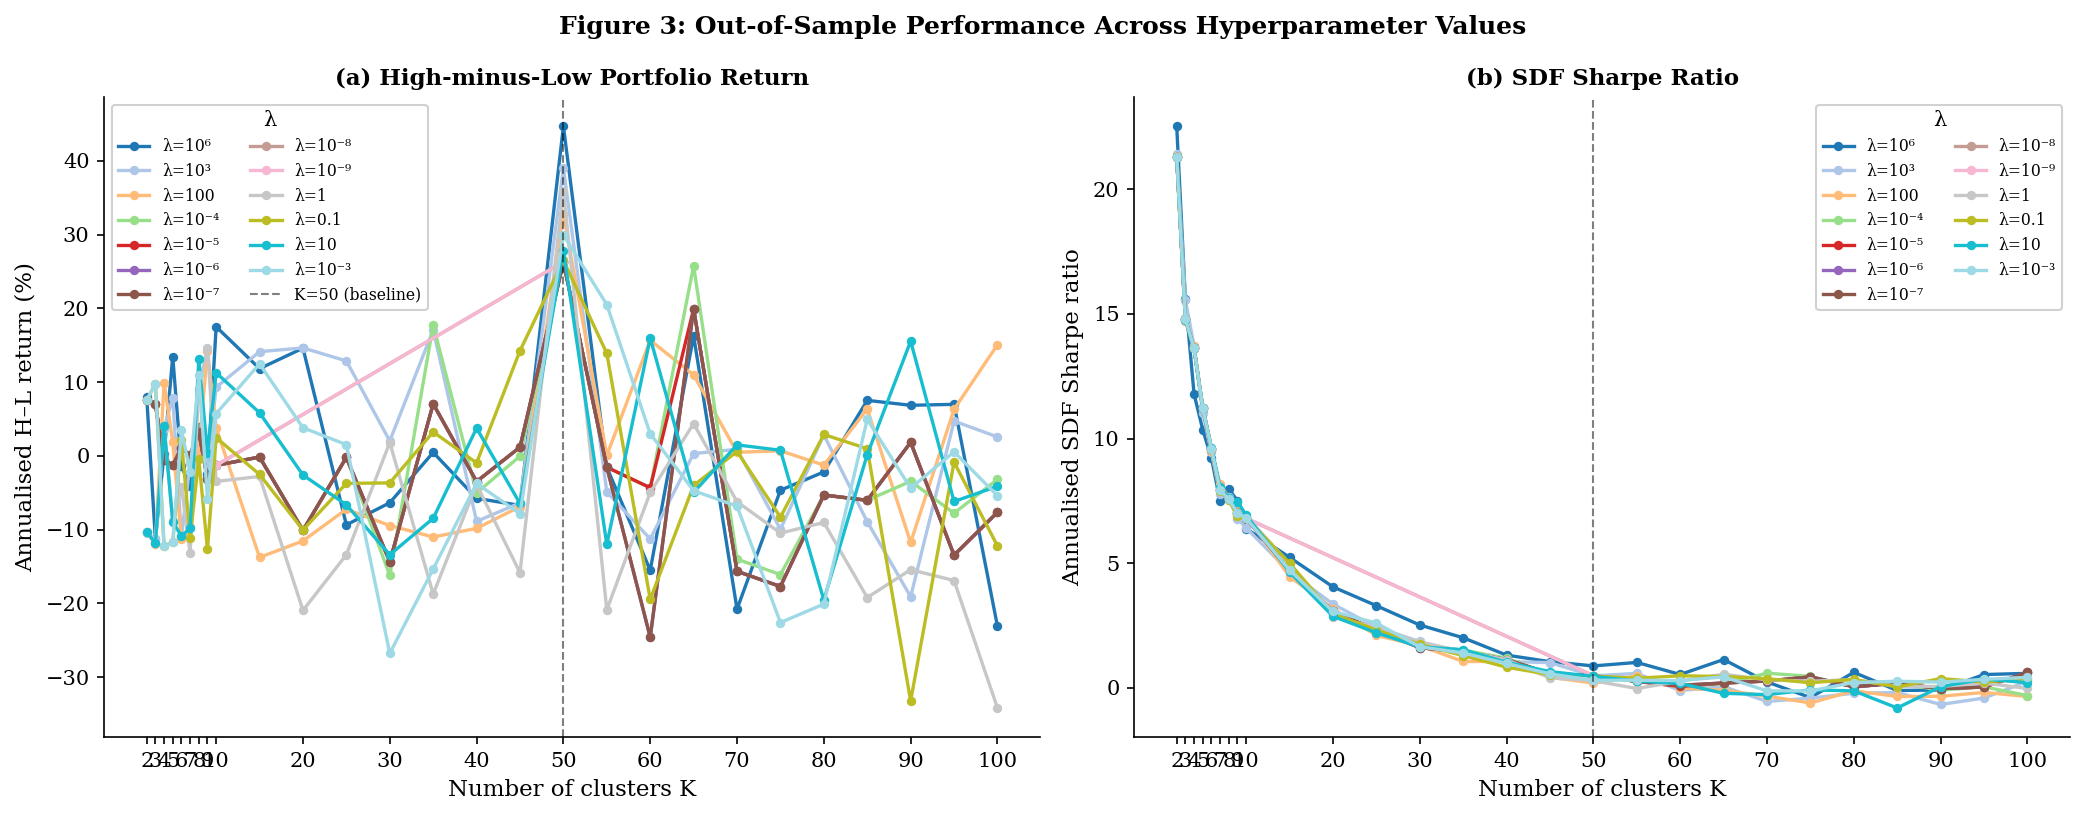

Figure 3 saved.


In [8]:
# ── Figure 3: Line charts (K on x-axis, one line per λ) ───────────
# Colour palette: one colour per λ value
n_lam  = len(RANKING_LAMBDA_STRS)
cmap   = cm.get_cmap("tab20", n_lam)

# Human-readable λ labels for the legend
def pretty_lam(lam_str):
    val = LAMBDA_STR_TO_FLOAT.get(lam_str, None)
    if val is None: return lam_str
    if   val >= 1e9:  return "10⁹"
    elif val >= 1e8:  return "10⁸"
    elif val >= 1e7:  return "10⁷"
    elif val >= 1e6:  return "10⁶"
    elif val >= 1e5:  return "10⁵"
    elif val >= 1e4:  return "10⁴"
    elif val >= 1e3:  return "10³"
    elif val >= 1e2:  return "100"
    elif val >= 10:   return "10"
    elif val >= 1:    return "1"
    elif val >= 0.1:  return "0.1"
    elif val >= 0.01: return "0.01"
    elif val >= 1e-3: return "10⁻³"
    elif val >= 1e-4: return "10⁻⁴"
    elif val >= 1e-5: return "10⁻⁵"
    elif val >= 1e-6: return "10⁻⁶"
    elif val >= 1e-7: return "10⁻⁷"
    elif val >= 1e-8: return "10⁻⁸"
    else:             return "10⁻⁹"

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Panel (a): H–L ────────────────────────────────────────────────
ax = axes[0]
for j, lam_str in enumerate(RANKING_LAMBDA_STRS):
    row = hl_mat[lam_str].dropna()
    if len(row) < 2: continue
    ax.plot(row.index.astype(int), row.values,
            color=cmap(j), linewidth=1.6,
            marker="o", markersize=3.5,
            label=f"λ={pretty_lam(lam_str)}")

ax.axvline(50, color="black", linestyle="--", linewidth=1.0,
           alpha=0.5, label="K=50 (baseline)")
ax.set_xlabel("Number of clusters K", fontsize=11)
ax.set_ylabel("Annualised H–L return (%)", fontsize=11)
ax.set_title("(a) High-minus-Low Portfolio Return", fontweight="bold", fontsize=11)
ax.set_xticks([k for k in K_GRID if k % 10 == 0 or k <= 10])
ax.legend(title="λ", ncol=2, fontsize=7.5, loc="upper left",
          bbox_to_anchor=(0, 1), framealpha=0.9)

# ── Panel (b): SDF Sharpe ratio ────────────────────────────────────
ax = axes[1]
for j, lam_str in enumerate(RANKING_LAMBDA_STRS):
    row = sr_mat[lam_str].dropna()
    if len(row) < 2: continue
    ax.plot(row.index.astype(int), row.values,
            color=cmap(j), linewidth=1.6,
            marker="o", markersize=3.5,
            label=f"λ={pretty_lam(lam_str)}")

ax.axvline(50, color="black", linestyle="--", linewidth=1.0, alpha=0.5)
ax.set_xlabel("Number of clusters K", fontsize=11)
ax.set_ylabel("Annualised SDF Sharpe ratio", fontsize=11)
ax.set_title("(b) SDF Sharpe Ratio", fontweight="bold", fontsize=11)
ax.set_xticks([k for k in K_GRID if k % 10 == 0 or k <= 10])
ax.legend(title="λ", ncol=2, fontsize=7.5, loc="upper right",
          bbox_to_anchor=(1, 1), framealpha=0.9)

fig.suptitle(
    "Figure 3: Out-of-Sample Performance Across Hyperparameter Values",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
save_figure(fig, "Figure3_HL_and_SDF_SR")
plt.show()
print("Figure 3 saved.")